# Figure 7 — PRJNA671738 metatranscriptome profiling

Visualize sylph profiling of 58 nasal metatranscriptomes against UHVDB r6 species reps + GTDB r214:

1. **Species richness** — number of DNA and RNA virus species detected per sample
2. **Taxonomic abundance** — relative abundance of DNA viruses, RNA viruses, and bacteria per sample
3. **RNA virus depth scatter** — unpaired sylph vs supplemental depths for RSV / HCoV / HRV subtypes (≥3)

Virus nucleic-acid type is assigned from UHVDB `genomad_taxonomy` realm:
- **RNA**: `Riboviria`
- **DNA**: `Duplodnaviria`, `Monodnaviria`, `Varidnaviria`
- Bacteria come from GTDB hits (`gtdb_genomes_reps_r214`).

In [10]:
from pathlib import Path
import csv
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

OUT = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7")
RESULTS = OUT / "results"
PLOTS = OUT / "plots"
PLOTS.mkdir(exist_ok=True)

METADATA = (
    Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB")
    / "uhvdb-manuscript-update/figure_1/uhvdb_v6_metadata_sra.tsv"
)
SAMPLES_TSV = OUT / "samples.tsv"

RNA_REALMS = {"Riboviria"}
DNA_REALMS = {"Duplodnaviria", "Monodnaviria", "Varidnaviria"}

COLORS = {
    "DNA virus": "#2E86AB",
    "RNA virus": "#D62828",
    "Bacteria": "#6A994E",
    "Unclassified virus": "#9B9B9B",
}

sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})
print("OUT:", OUT)
print("results dirs:", sum(1 for p in RESULTS.iterdir() if p.is_dir()))

OUT: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7
results dirs: 58


## 1. Map UHVDB species reps → DNA / RNA

In [11]:
def load_species_nucleic_type(metadata_path: Path) -> dict[str, str]:
    """Return species_rep → DNA | RNA | Unclassified from geNomad realm."""
    rep_type: dict[str, str] = {}
    with metadata_path.open() as fh:
        for row in csv.DictReader(fh, delimiter="\t"):
            srep = (row.get("species_rep") or "").strip()
            if not srep or srep in rep_type:
                continue
            tax = row.get("genomad_taxonomy") or ""
            parts = tax.split(";")
            realm = parts[1] if len(parts) > 1 else ""
            if realm in RNA_REALMS:
                rep_type[srep] = "RNA virus"
            elif realm in DNA_REALMS:
                rep_type[srep] = "DNA virus"
            else:
                rep_type[srep] = "Unclassified virus"
    return rep_type


rep_type = load_species_nucleic_type(METADATA)
print("species reps classified:", len(rep_type))
print(Counter(rep_type.values()))

species reps classified: 291605
Counter({'DNA virus': 282576, 'RNA virus': 5359, 'Unclassified virus': 3670})


## 2. Aggregate sylph profiles

In [12]:
def classify_hit(genome_file: str, contig_name: str, rep_type: dict[str, str]) -> str:
    if "gtdb" in genome_file:
        return "Bacteria"
    if "uhvdb" in genome_file:
        cid = contig_name.split()[0]
        return rep_type.get(cid, "Unclassified virus")
    return "Other"


def load_sample_list() -> list[str]:
    if SAMPLES_TSV.is_file():
        with SAMPLES_TSV.open() as fh:
            return [row["sample"] for row in csv.DictReader(fh, delimiter="\t")]
    return sorted(p.name for p in RESULTS.iterdir() if p.is_dir())


def summarize_profiles(samples: list[str], rep_type: dict[str, str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (per-hit long table, per-sample summary)."""
    rows = []
    summaries = []
    missing = Counter()

    for sample in samples:
        prof = RESULTS / sample / f"{sample}.profile.tsv"
        if not prof.is_file() or prof.stat().st_size == 0:
            continue

        species_sets = {
            "DNA virus": set(),
            "RNA virus": set(),
            "Unclassified virus": set(),
        }
        abund = {
            "DNA virus": 0.0,
            "RNA virus": 0.0,
            "Bacteria": 0.0,
            "Unclassified virus": 0.0,
            "Other": 0.0,
        }

        with prof.open() as fh:
            for row in csv.DictReader(fh, delimiter="\t"):
                ab = float(row["Taxonomic_abundance"])
                genome_file = row["Genome_file"]
                contig = row["Contig_name"]
                cat = classify_hit(genome_file, contig, rep_type)
                if cat == "Unclassified virus" and "uhvdb" in genome_file:
                    cid = contig.split()[0]
                    if cid not in rep_type:
                        missing[cid] += 1

                abund[cat] = abund.get(cat, 0.0) + ab
                if cat in species_sets:
                    species_sets[cat].add(contig.split()[0])

                rows.append({
                    "sample": sample,
                    "category": cat,
                    "contig": contig.split()[0],
                    "taxonomic_abundance": ab,
                    "sequence_abundance": float(row["Sequence_abundance"]),
                    "ani": float(row["Adjusted_ANI"]),
                })

        summaries.append({
            "sample": sample,
            "n_dna_species": len(species_sets["DNA virus"]),
            "n_rna_species": len(species_sets["RNA virus"]),
            "n_unclassified_virus_species": len(species_sets["Unclassified virus"]),
            "n_virus_species": (
                len(species_sets["DNA virus"])
                + len(species_sets["RNA virus"])
                + len(species_sets["Unclassified virus"])
            ),
            "abund_dna": abund["DNA virus"],
            "abund_rna": abund["RNA virus"],
            "abund_bacteria": abund["Bacteria"],
            "abund_unclassified_virus": abund["Unclassified virus"],
            "abund_other": abund["Other"],
            "abund_total": sum(abund.values()),
        })

    hits = pd.DataFrame(rows)
    summary = pd.DataFrame(summaries).sort_values("sample").reset_index(drop=True)
    if missing:
        print(f"WARNING: {len(missing)} UHVDB IDs missing from metadata (first 5): {missing.most_common(5)}")
    else:
        print("All UHVDB hits matched to metadata.")
    return hits, summary


samples = load_sample_list()
hits, summary = summarize_profiles(samples, rep_type)
print(f"samples with profiles: {len(summary)}")
print(f"total profile hits: {len(hits)}")
display(summary.describe().round(2))

All UHVDB hits matched to metadata.
samples with profiles: 58
total profile hits: 915


,n_dna_species,n_rna_species,n_unclassified_virus_species,n_virus_species,abund_dna,abund_rna,abund_bacteria,abund_unclassified_virus,abund_other,abund_total
count,58.0,58.00,58.00,58.00,58.00,58.00,58.00,58.00,58.0,58.0
mean,4.4,4.62,0.02,9.03,14.66,68.45,16.89,0.00,0.0,100.0
std,2.5,1.73,0.13,3.12,17.80,33.14,19.50,0.03,0.0,0.0
min,0.0,1.00,0.00,4.00,0.00,1.91,0.00,0.00,0.0,100.0
25%,2.0,4.00,0.00,7.00,0.83,35.24,1.04,0.00,0.0,100.0
50%,4.0,4.00,0.00,8.00,4.92,81.61,7.87,0.00,0.0,100.0
75%,6.0,6.00,0.00,10.00,26.09,97.34,25.59,0.00,0.0,100.0
max,11.0,10.00,1.00,18.00,63.06,100.00,66.72,0.25,0.0,100.0


In [13]:
# Sort samples by RNA taxonomic abundance (dominant signal in these metatranscriptomes)
summary_plot = summary.sort_values("abund_rna", ascending=False).reset_index(drop=True)
sample_order = summary_plot["sample"].tolist()

summary_path = OUT / "sample_summary.tsv"
summary.to_csv(summary_path, sep="\t", index=False)
print(f"wrote {summary_path}")
summary_plot.head()

wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7/sample_summary.tsv


,sample,n_dna_species,n_rna_species,n_unclassified_virus_species,n_virus_species,abund_dna,abund_rna,abund_bacteria,abund_unclassified_virus,abund_other,abund_total
0,SRR12904863,1,7,0,8,0.0035,99.9965,0.0000,0.0,0.0,100.0000
1,SRR12904853,2,6,0,8,0.0089,99.9903,0.0009,0.0,0.0,100.0001
2,SRR12904850,3,8,0,11,0.0192,99.9591,0.0215,0.0,0.0,99.9998
3,SRR12904861,0,4,0,4,0.0000,99.9143,0.0855,0.0,0.0,99.9998
4,SRR12904862,1,5,0,6,0.0082,99.9055,0.0861,0.0,0.0,99.9998


## 3. DNA / RNA virus species per sample

wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7/plots/figure_7_virus_species_richness.png


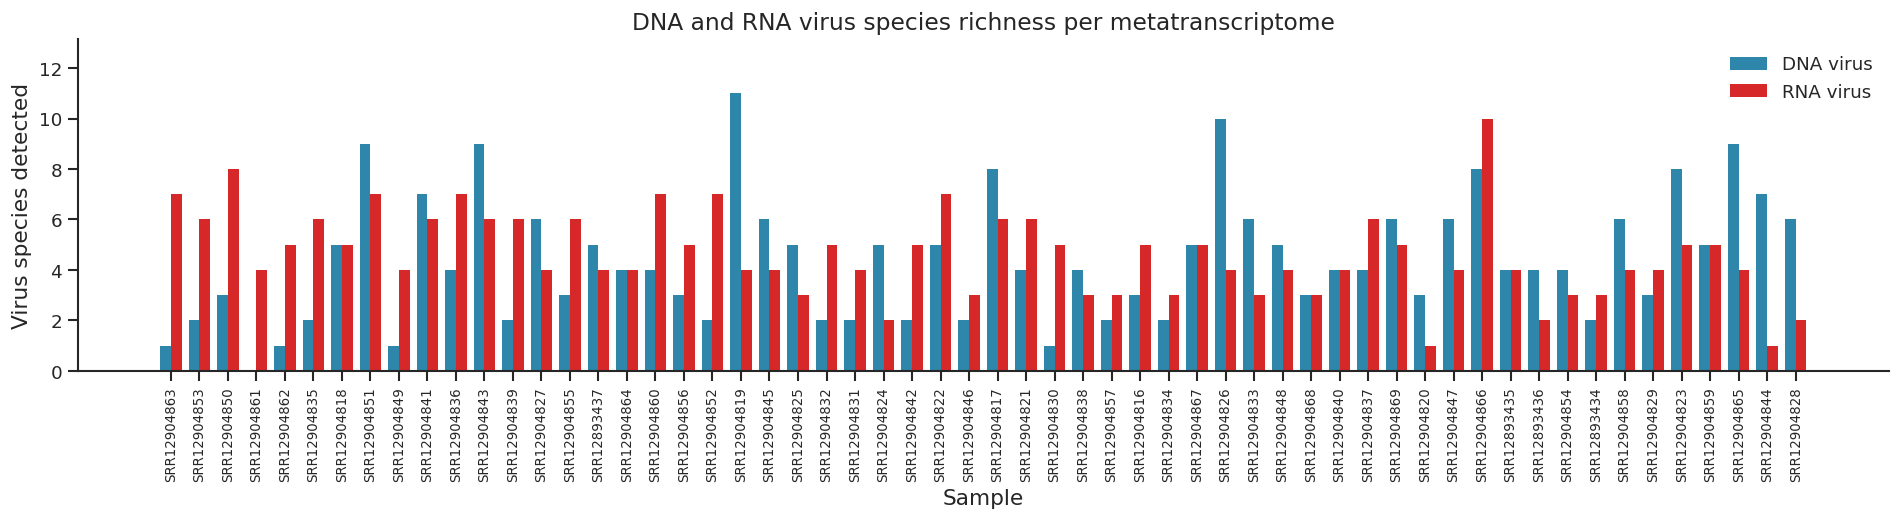

DNA species/sample: median=4, range=0-11
RNA species/sample: median=4, range=1-10


In [14]:
richness = summary_plot.melt(
    id_vars=["sample"],
    value_vars=["n_dna_species", "n_rna_species"],
    var_name="group",
    value_name="n_species",
)
richness["group"] = richness["group"].map({
    "n_dna_species": "DNA virus",
    "n_rna_species": "RNA virus",
})

fig, ax = plt.subplots(figsize=(16, 4.5))
x = np.arange(len(sample_order))
width = 0.38

dna_vals = summary_plot.set_index("sample").loc[sample_order, "n_dna_species"].to_numpy()
rna_vals = summary_plot.set_index("sample").loc[sample_order, "n_rna_species"].to_numpy()

ax.bar(x - width / 2, dna_vals, width, label="DNA virus", color=COLORS["DNA virus"], edgecolor="none")
ax.bar(x + width / 2, rna_vals, width, label="RNA virus", color=COLORS["RNA virus"], edgecolor="none")

ax.set_xticks(x)
ax.set_xticklabels(sample_order, rotation=90, fontsize=8)
ax.set_ylabel("Virus species detected")
ax.set_xlabel("Sample")
ax.set_title("DNA and RNA virus species richness per metatranscriptome")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(0, max(dna_vals.max(), rna_vals.max()) * 1.15 + 0.5)
sns.despine(ax=ax)
fig.tight_layout()

out = PLOTS / "figure_7_virus_species_richness.png"
fig.savefig(out, bbox_inches="tight")
print(f"wrote {out}")
plt.show()

print(
    f"DNA species/sample: median={np.median(dna_vals):.0f}, "
    f"range={dna_vals.min()}-{dna_vals.max()}"
)
print(
    f"RNA species/sample: median={np.median(rna_vals):.0f}, "
    f"range={rna_vals.min()}-{rna_vals.max()}"
)

## 4. Taxonomic abundance: DNA viruses, RNA viruses, bacteria

wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7/plots/figure_7_taxonomic_abundance.png


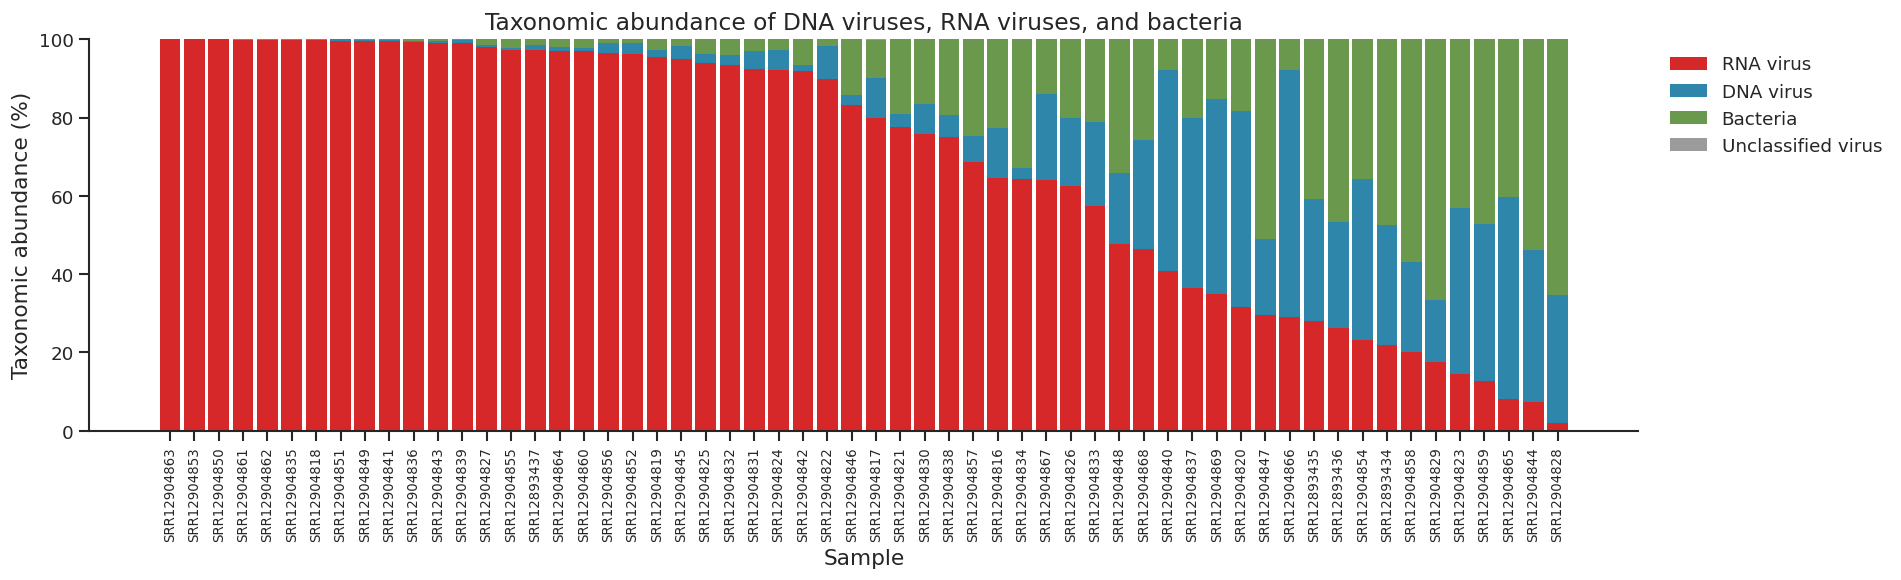

Median taxonomic abundance — RNA=81.6%, DNA=4.9%, Bacteria=7.9%


In [15]:
# Stacked bars of taxonomic abundance (%). Unclassified virus is included if present.
abund_cols = [
    ("abund_rna", "RNA virus"),
    ("abund_dna", "DNA virus"),
    ("abund_bacteria", "Bacteria"),
]
if summary_plot["abund_unclassified_virus"].sum() > 0:
    abund_cols.append(("abund_unclassified_virus", "Unclassified virus"))

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(sample_order))
bottom = np.zeros(len(sample_order))

for col, label in abund_cols:
    vals = summary_plot.set_index("sample").loc[sample_order, col].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        width=0.85,
        label=label,
        color=COLORS[label],
        edgecolor="none",
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(sample_order, rotation=90, fontsize=8)
ax.set_ylabel("Taxonomic abundance (%)")
ax.set_xlabel("Sample")
ax.set_title("Taxonomic abundance of DNA viruses, RNA viruses, and bacteria")
ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
sns.despine(ax=ax)
fig.tight_layout()

out = PLOTS / "figure_7_taxonomic_abundance.png"
fig.savefig(out, bbox_inches="tight")
print(f"wrote {out}")
plt.show()

print(
    "Median taxonomic abundance — "
    f"RNA={summary['abund_rna'].median():.1f}%, "
    f"DNA={summary['abund_dna'].median():.1f}%, "
    f"Bacteria={summary['abund_bacteria'].median():.1f}%"
)

## 5. Compact summary panels (optional manuscript layout)

wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7/plots/figure_7_combined.png


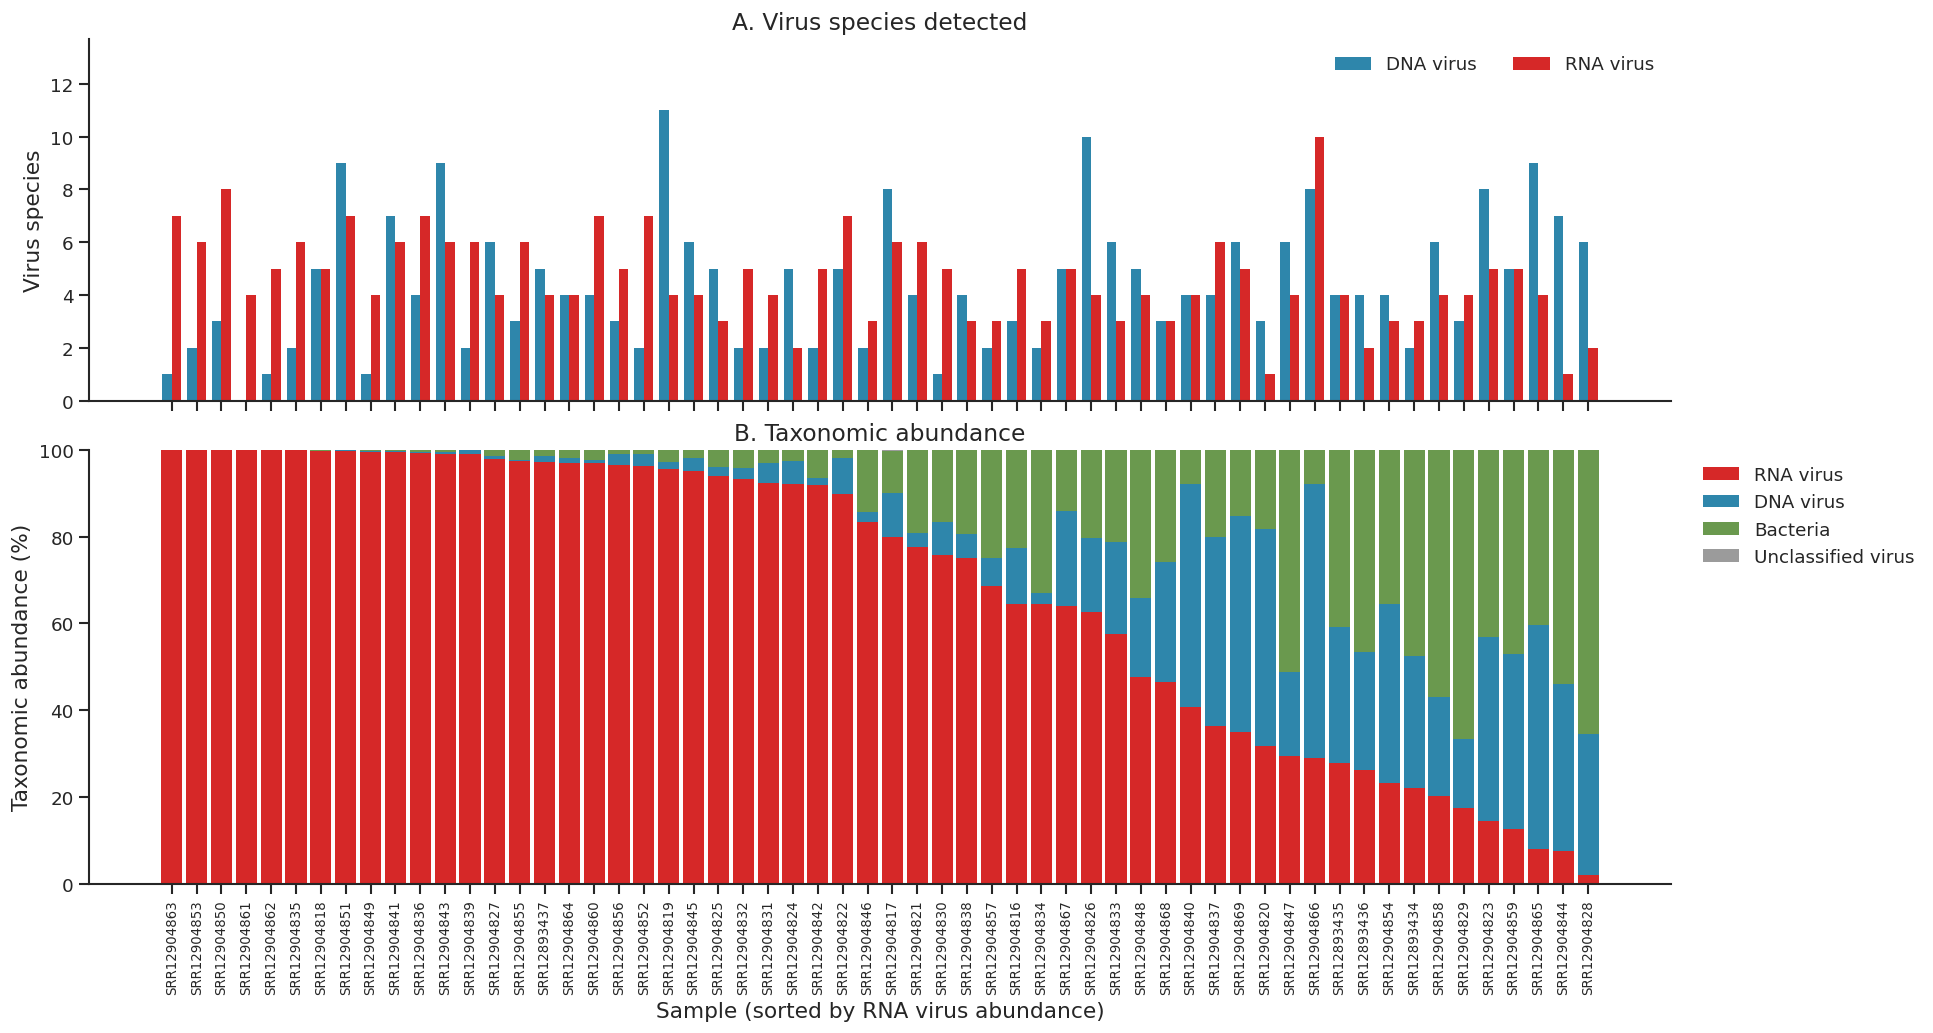

In [16]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 8.5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 1.2]},
)

# Panel A — richness
ax = axes[0]
ax.bar(x - width / 2, dna_vals, width, label="DNA virus", color=COLORS["DNA virus"], edgecolor="none")
ax.bar(x + width / 2, rna_vals, width, label="RNA virus", color=COLORS["RNA virus"], edgecolor="none")
ax.set_ylabel("Virus species")
ax.set_title("A. Virus species detected")
ax.legend(frameon=False, ncol=2, loc="upper right")
ax.set_ylim(0, max(dna_vals.max(), rna_vals.max()) * 1.2 + 0.5)
sns.despine(ax=ax)

# Panel B — abundance
ax = axes[1]
bottom = np.zeros(len(sample_order))
for col, label in abund_cols:
    vals = summary_plot.set_index("sample").loc[sample_order, col].to_numpy()
    ax.bar(x, vals, bottom=bottom, width=0.85, label=label, color=COLORS[label], edgecolor="none")
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(sample_order, rotation=90, fontsize=8)
ax.set_ylabel("Taxonomic abundance (%)")
ax.set_xlabel("Sample (sorted by RNA virus abundance)")
ax.set_title("B. Taxonomic abundance")
ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
sns.despine(ax=ax)

out = PLOTS / "figure_7_combined.png"
fig.savefig(out, bbox_inches="tight")
print(f"wrote {out}")
plt.show()


## 6. Quick QC checks

In [17]:
print("Samples:", len(summary))
print("Profiles with total taxonomic abundance outside 99–101%:")
bad = summary[(summary["abund_total"] < 99) | (summary["abund_total"] > 101)]
print(bad[["sample", "abund_total"]] if len(bad) else "  none")

print("\nTop RNA-dominated samples:")
display(
    summary_plot[["sample", "n_dna_species", "n_rna_species", "abund_dna", "abund_rna", "abund_bacteria"]]
    .head(10)
    .round(2)
)

print("\nMost bacteria-rich samples:")
display(
    summary.sort_values("abund_bacteria", ascending=False)[
        ["sample", "n_dna_species", "n_rna_species", "abund_dna", "abund_rna", "abund_bacteria"]
    ]
    .head(10)
    .round(2)
)

Samples: 58
Profiles with total taxonomic abundance outside 99–101%:
  none

Top RNA-dominated samples:


,sample,n_dna_species,n_rna_species,abund_dna,abund_rna,abund_bacteria
0,SRR12904863,1,7,0.00,100.00,0.00
1,SRR12904853,2,6,0.01,99.99,0.00
2,SRR12904850,3,8,0.02,99.96,0.02
3,SRR12904861,0,4,0.00,99.91,0.09
4,SRR12904862,1,5,0.01,99.91,0.09
5,SRR12904835,2,6,0.04,99.85,0.11
6,SRR12904818,5,5,0.06,99.69,0.25
7,SRR12904851,9,7,0.33,99.61,0.06
8,SRR12904849,1,4,0.23,99.60,0.17
9,SRR12904841,7,6,0.23,99.48,0.28



Most bacteria-rich samples:


,sample,n_dna_species,n_rna_species,abund_dna,abund_rna,abund_bacteria
17,SRR12904829,3,4,15.75,17.53,66.72
16,SRR12904828,6,2,32.68,1.91,65.41
46,SRR12904858,6,4,22.96,20.18,56.86
32,SRR12904844,7,1,38.59,7.46,53.96
35,SRR12904847,6,4,19.41,29.50,51.09
0,SRR12893434,2,3,30.52,22.00,47.48
47,SRR12904859,5,5,40.12,12.73,47.16
2,SRR12893436,4,2,27.14,26.17,46.70
11,SRR12904823,8,5,42.38,14.40,43.22
1,SRR12893435,4,4,31.17,27.92,40.91


## 7. Unpaired RNA virus depth scatter (sylph vs supplemental)

Manuscript-style multi-panel figure comparing **unpaired** RNA-virus depths at coverage ≥ 3.

Subtypes from ICTV species, merging:
1. **New** `uhvdb_taxonomy.tsv.gz` (`Species`) — preferred when present
2. **Old** `uhvdb_v6_metadata_sra.tsv` (`ictv_species`) — fallback for genomes missing from the new file

RSV-A vs RSV-B is not split by ICTV (`Orthopneumovirus hominis`). Those genomes are further labeled via BLAST subtype calls propagated by UHVDB `species_cluster_id` (see `rsv_species_cluster_AB.tsv`).

| ICTV species | Subtype |
|---|---|
| `Orthopneumovirus hominis` + BLAST/cluster | RSV-A / RSV-B |
| `Alphacoronavirus amsterdamense` | NL63 |
| `Betacoronavirus gravedinis` | OC43 |
| `Alphacoronavirus chicagoense` | 229E |
| `Enterovirus alpharhino` / `betarhino` / `cerhino` | HRV-A / B / C |
| `Bocaparvovirus primate1/2` | HBoV* |

\* HBoV supplemental count is presence (mmc4 metatranscriptomic; 1 detection) — no avg-depth column in mmc2.


In [39]:
TAXONOMY = (
    Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB")
    / "uhvdb-manuscript-update/figure_1/results/uhvdb_toolkit/toolkit/taxonomy"
    / "uhvdb_taxonomy/uhvdb_taxonomy.tsv.gz"
)
MMC2 = Path("/tmp/prjna671738_supp/extracted/mmc2.xls")
IDMAP = OUT / "uhvdb_virus_subtype_map.tsv"
IDMAP_DETAIL = OUT / "uhvdb_virus_subtype_map_ictv.tsv"
BLAST_MAP = OUT / "uhvdb_virus_subtype_map.blast.tsv"
RSV_AB = OUT / "rsv_species_cluster_AB.tsv"
MATCHES = OUT / "likely_phenotype_matches.tsv"

SPECIES_TO_SUBTYPE = {
    "Orthopneumovirus hominis": "RSV",  # split to RSVA/RSVB below
    "Alphacoronavirus amsterdamense": "NL63",
    "Betacoronavirus gravedinis": "OC43",
    "Alphacoronavirus chicagoense": "229E",
    "Enterovirus alpharhino": "HRV_A",
    "Enterovirus betarhino": "HRV_B",
    "Enterovirus cerhino": "HRV_C",
    "Bocaparvovirus primate1": "HBoV",
    "Bocaparvovirus primate2": "HBoV",
    "Bocaparvovirus primate3": "HBoV",
}

# Prefer new taxonomy Species; fall back to old metadata ictv_species
new_tax = pd.read_csv(
    TAXONOMY, sep="\t", compression="gzip",
    usecols=["uhvdb_id", "Species", "Genus", "Family", "normscore", "ref"],
).drop_duplicates("uhvdb_id").rename(columns={
    "Species": "species_new", "Genus": "genus_new", "Family": "family_new",
    "normscore": "normscore_new", "ref": "ref_new",
})
old_tax = pd.read_csv(
    METADATA, sep="\t",
    usecols=["uhvdb_id", "ictv_species", "ictv_genus", "ictv_family", "species_cluster_id"],
    low_memory=False,
).drop_duplicates("uhvdb_id").rename(columns={
    "ictv_species": "species_old", "ictv_genus": "genus_old", "ictv_family": "family_old",
})
merged = old_tax.merge(new_tax, on="uhvdb_id", how="outer")
merged["species"] = merged["species_new"].fillna(merged["species_old"])
merged["genus"] = merged["genus_new"].fillna(merged["genus_old"])
merged["family"] = merged["family_new"].fillna(merged["family_old"])
merged["source"] = "new_only"
merged.loc[merged["species_new"].isna() & merged["species_old"].notna(), "source"] = "old_fallback"
merged.loc[
    merged["species_new"].notna() & merged["species_old"].notna()
    & (merged["species_new"] != merged["species_old"]),
    "source",
] = "new_overrides_old"

mapped = merged[merged["species"].isin(SPECIES_TO_SUBTYPE)].copy()
mapped["subtype"] = mapped["species"].map(SPECIES_TO_SUBTYPE)

# Split RSV → RSVA/RSVB using BLAST labels propagated by species_cluster_id
blast = pd.read_csv(BLAST_MAP, sep="\t")
blast_rsv = blast[blast["subtype"].isin(["RSVA", "RSVB"])].merge(
    mapped.loc[mapped["subtype"] == "RSV", ["uhvdb_id", "species_cluster_id"]],
    on="uhvdb_id",
    how="inner",
)
cluster_calls = (
    blast_rsv.groupby("species_cluster_id")["subtype"]
    .agg(lambda s: s.mode().iloc[0] if s.nunique() == 1 else "MIXED")
)
# Keep prior detected-cluster table in sync when available
cluster_call_map = cluster_calls[cluster_calls.isin(["RSVA", "RSVB"])].to_dict()
rsv_mask = mapped["subtype"] == "RSV"
mapped.loc[rsv_mask, "subtype"] = mapped.loc[rsv_mask, "species_cluster_id"].map(cluster_call_map)
n_unsplit = int((mapped["subtype"] == "RSV").sum()) if "RSV" in mapped["subtype"].values else int(mapped["subtype"].isna().sum())
# drop any RSV genomes that could not be split
mapped = mapped[mapped["subtype"].isin(
    ["RSVA", "RSVB", "NL63", "OC43", "229E", "HRV_A", "HRV_B", "HRV_C", "HBoV"]
)].copy()

ab_tbl = (
    pd.DataFrame({"species_cluster_id": list(cluster_call_map.keys()),
                  "call": list(cluster_call_map.values())})
    .sort_values(["call", "species_cluster_id"])
)
ab_tbl.to_csv(RSV_AB, sep="\t", index=False)

detail = mapped[[
    "uhvdb_id", "subtype", "species", "genus", "family", "source",
    "species_cluster_id", "species_new", "species_old", "normscore_new", "ref_new",
]].sort_values(["subtype", "uhvdb_id"])
detail.to_csv(IDMAP_DETAIL, sep="\t", index=False)
detail[["uhvdb_id", "subtype"]].to_csv(IDMAP, sep="\t", index=False)
print("Wrote", IDMAP.name, "and", IDMAP_DETAIL.name, f"({len(detail)} genomes)")
print(detail.groupby(["subtype", "species"]).size().to_string())
print("RSV cluster A/B calls:", ab_tbl["call"].value_counts().to_dict(), f"(unsplit dropped: {n_unsplit})")
print("Assignment source:", detail["source"].value_counts().to_dict())

VIRUS_AXES = ["RSVA", "RSVB", "NL63", "OC43", "229E", "HRV_A", "HRV_B", "HRV_C", "HBoV"]
VIRUS_LABELS = {
    "RSVA": "RSV-A",
    "RSVB": "RSV-B",
    "NL63": "HCoV-NL63",
    "OC43": "HCoV-OC43",
    "229E": "HCoV-229E",
    "HRV_A": "HRV-A",
    "HRV_B": "HRV-B",
    "HRV_C": "HRV-C",
    "HBoV": "HBoV*",
}
COV_THR = 3.0

id2sub = dict(zip(detail["uhvdb_id"], detail["subtype"]))
ph = pd.read_csv(MATCHES, sep="\t").set_index("sample")


def load_sylph_virus_depths():
    rows, pos, n = [], {a: 0 for a in VIRUS_AXES}, 0
    for d in sorted(RESULTS.iterdir()):
        prof = d / f"{d.name}.profile.tsv"
        if not d.is_dir() or not prof.is_file():
            continue
        n += 1
        vfp = {a: 0.0 for a in VIRUS_AXES}
        with prof.open() as fh:
            for row in csv.DictReader(fh, delimiter="\t"):
                if "uhvdb" not in row["Genome_file"]:
                    continue
                sub = id2sub.get(row["Contig_name"].split()[0])
                if sub in vfp:
                    vfp[sub] = max(vfp[sub], float(row["True_cov"]))
        for a in VIRUS_AXES:
            if vfp[a] >= COV_THR:
                pos[a] += 1
                rows.append({"source": "Sylph", "virus_key": a, "depth": vfp[a]})
    return rows, pos, n


sylph_rows, pos_s, n_s = load_sylph_virus_depths()

supp2 = pd.read_excel(MMC2, sheet_name=0)
supp_cols = {
    "RSVA": "RSVA_avg_read_Depth",
    "RSVB": "RSVB_avg_read_Depth",
    "NL63": "Coronavirus-NL63_average_read_depth",
    "OC43": "Coronavirus-OC43_average_read_depth",
    "229E": "Coronavirus-229E_average_read_depth",
    "HRV_A": "Rhinovirus-A_average_read_depth",
    "HRV_B": "Rhinovirus-B_average_read_depth",
    "HRV_C": "Rhinovirus-C_average_read_depth",
}
supp_rows, pos_t = [], {a: 0 for a in VIRUS_AXES}
for _, r in supp2.iterrows():
    depths = {a: float(pd.to_numeric(r[col], errors="coerce") or 0.0) for a, col in supp_cols.items()}
    depths["HBoV"] = 0.0  # no depth column in mmc2
    for a in VIRUS_AXES:
        if depths[a] >= COV_THR:
            pos_t[a] += 1
            supp_rows.append({"source": "Supplemental", "virus_key": a, "depth": depths[a]})
n_t = len(supp2)
# mmc4 reports 1 bocavirus metatranscriptomic detection (coverage %, no avg depth in mmc2)
pos_t["HBoV"] = 1
depth_long = pd.DataFrame(sylph_rows + supp_rows)
print(f"Sylph samples: {n_s}; supplemental rows: {n_t}; points ≥{COV_THR:g}: {len(depth_long)}")
print("Detections ≥3 (sylph / supp):", {a: f"{pos_s[a]}/{pos_t[a]}" for a in VIRUS_AXES})
print("Note: HBoV supplemental count is presence from mmc4 (1 MT detection), not mmc2 depth ≥3")
depth_long.head()


Wrote uhvdb_virus_subtype_map.tsv and uhvdb_virus_subtype_map_ictv.tsv (4973 genomes)
subtype  species                       
229E     Alphacoronavirus chicagoense        77
HBoV     Bocaparvovirus primate1            124
         Bocaparvovirus primate2            119
HRV_A    Enterovirus alpharhino             561
HRV_B    Enterovirus betarhino              145
HRV_C    Enterovirus cerhino                335
NL63     Alphacoronavirus amsterdamense     107
OC43     Betacoronavirus gravedinis         129
RSVA     Orthopneumovirus hominis          2024
RSVB     Orthopneumovirus hominis          1352
RSV cluster A/B calls: {'RSVA': 8, 'RSVB': 7} (unsplit dropped: 14)
Assignment source: {'new_only': 4764, 'old_fallback': 209}
Sylph samples: 58; supplemental rows: 58; points ≥3: 163
Detections ≥3 (sylph / supp): {'RSVA': '46/47', 'RSVB': '16/15', 'NL63': '2/2', 'OC43': '1/1', '229E': '1/1', 'HRV_A': '8/9', 'HRV_B': '4/4', 'HRV_C': '3/2', 'HBoV': '1/1'}
Note: HBoV supplemental count is pres

,source,virus_key,depth
0,Sylph,229E,16.006
1,Sylph,OC43,20.577
2,Sylph,NL63,26.831
3,Sylph,NL63,1763.793
4,Sylph,HRV_C,5.893


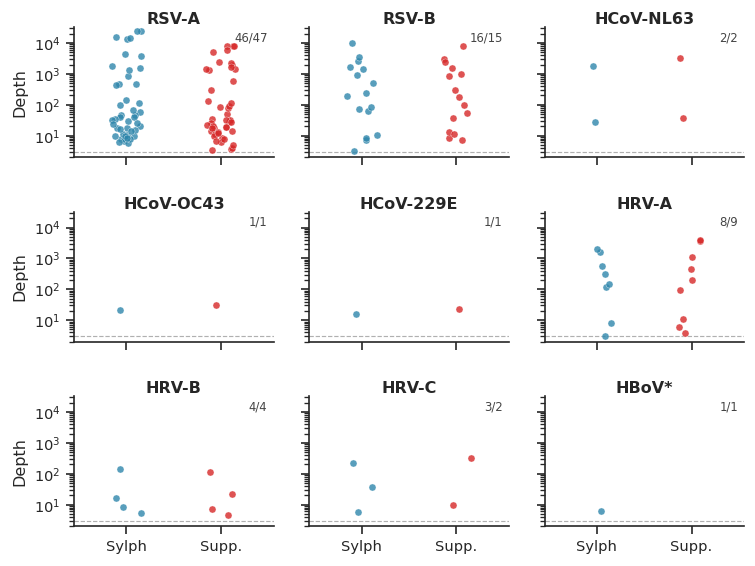

wrote figure_7_virus_depth_scatter


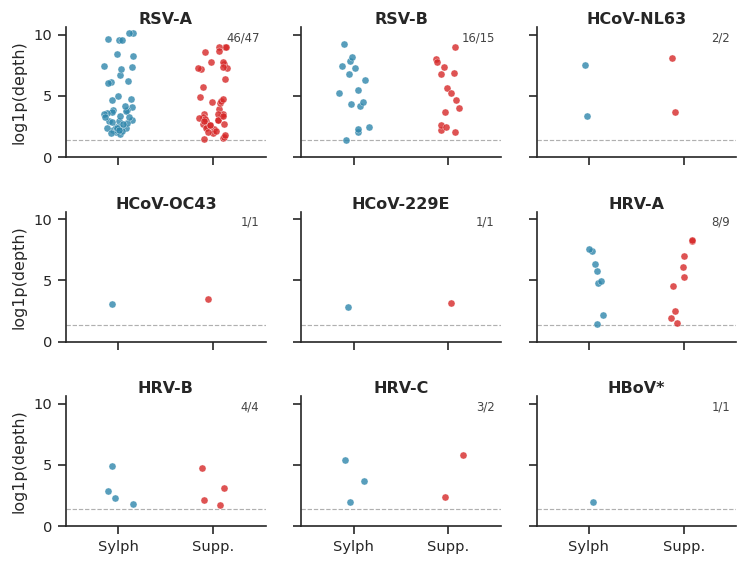

wrote figure_7_virus_depth_scatter_log1p


In [42]:
# Manuscript styling for this figure only (restored afterward)
_saved_rc = plt.rcParams.copy()
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})
sns.set_theme(style="ticks", context="paper", rc=plt.rcParams)

TOOL_COLORS = {"Sylph": "#2E86AB", "Supplemental": "#D62828"}


def make_virus_depth_scatter(ycol, ylabel, yscale, ylim, out_stem):
    fig, axes = plt.subplots(
        3, 3, figsize=(7.2, 5.4), sharey=True,
        gridspec_kw={"wspace": 0.18, "hspace": 0.42},
    )
    axes = axes.ravel()
    rng = np.random.default_rng(1)
    for i, a in enumerate(VIRUS_AXES):
        ax = axes[i]
        sub = depth_long[depth_long.virus_key == a]
        for j, src in enumerate(["Sylph", "Supplemental"]):
            dd = sub[sub.source == src]
            if dd.empty:
                continue
            x = j + rng.uniform(-0.16, 0.16, size=len(dd))
            y = np.log1p(dd["depth"]) if ycol == "log1p" else dd["depth"]
            ax.scatter(
                x, y, c=TOOL_COLORS[src], marker="o",
                s=18, alpha=0.8, edgecolors="white", linewidths=0.25, zorder=3,
            )
        if yscale == "log":
            ax.set_yscale("log")
        ax.set_ylim(*ylim)
        ax.set_xlim(-0.55, 1.55)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Sylph", "Supp."] if i >= 6 else [])
        ax.set_title(VIRUS_LABELS[a], fontweight="bold", pad=2)
        ax.text(
            0.97, 0.97, f"{pos_s[a]}/{pos_t[a]}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7, color="#444",
        )
        thr = np.log1p(COV_THR) if ycol == "log1p" else COV_THR
        ax.axhline(thr, color="#B0B0B0", lw=0.7, ls="--", zorder=1)
        sns.despine(ax=ax)
        ax.set_ylabel(ylabel if i % 3 == 0 else "")

    fig.savefig(PLOTS / f"{out_stem}.png")
    fig.savefig(PLOTS / f"{out_stem}.pdf")
    plt.show()
    print("wrote", out_stem)


ymax = float(depth_long.depth.max()) * 1.35 if len(depth_long) else 10.0
make_virus_depth_scatter("depth", "Depth", "log", (2.0, ymax), "figure_7_virus_depth_scatter")
make_virus_depth_scatter(
    "log1p", "log1p(depth)", None,
    (0.0, np.log1p(depth_long.depth.max()) * 1.05) if len(depth_long) else (0, 1),
    "figure_7_virus_depth_scatter_log1p",
)

# Restore notebook-wide theme
plt.rcParams.update(_saved_rc)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})


## 8. Species clusters detected per human virus

For each clinical subtype, count unique UHVDB `species_cluster_id`s among sylph hits at depth ≥ 3 (same threshold as the scatter). Also report the number of distinct genomes and positive samples.


In [41]:
# Requires §7 subtype map (id2sub / VIRUS_AXES / COV_THR). Rebuild from file if needed.
if "id2sub" not in globals() or "VIRUS_AXES" not in globals():
    _map = pd.read_csv(OUT / "uhvdb_virus_subtype_map.tsv", sep="\t")
    id2sub = dict(zip(_map["uhvdb_id"], _map["subtype"]))
    VIRUS_AXES = ["RSVA", "RSVB", "NL63", "OC43", "229E", "HRV_A", "HRV_B", "HRV_C", "HBoV"]
    COV_THR = 3.0

cluster_meta = pd.read_csv(
    METADATA, sep="\t",
    usecols=["uhvdb_id", "species_rep", "species_cluster_id"],
    low_memory=False,
).drop_duplicates("uhvdb_id")
id2cluster = dict(zip(cluster_meta["uhvdb_id"], cluster_meta["species_cluster_id"]))
id2srep = dict(zip(cluster_meta["uhvdb_id"], cluster_meta["species_rep"]))

hit_rows = []
for d in sorted(RESULTS.iterdir()):
    prof = d / f"{d.name}.profile.tsv"
    if not d.is_dir() or not prof.is_file():
        continue
    with prof.open() as fh:
        for row in csv.DictReader(fh, delimiter="\t"):
            if "uhvdb" not in row["Genome_file"]:
                continue
            uid = row["Contig_name"].split()[0]
            sub = id2sub.get(uid)
            if sub not in VIRUS_AXES:
                continue
            cov = float(row["True_cov"])
            if cov < COV_THR:
                continue
            hit_rows.append({
                "sample": d.name,
                "uhvdb_id": uid,
                "subtype": sub,
                "True_cov": cov,
                "species_cluster_id": id2cluster.get(uid),
                "species_rep": id2srep.get(uid),
            })

hits = pd.DataFrame(hit_rows)
if hits.empty:
    raise RuntimeError("No human-virus sylph hits at COV_THR; run §7 first or check IDMAP")

cluster_summary = (
    hits.groupby("subtype", sort=False)
    .agg(
        n_species_clusters=("species_cluster_id", "nunique"),
        n_genomes=("uhvdb_id", "nunique"),
        n_samples=("sample", "nunique"),
        n_hits=("uhvdb_id", "size"),
        max_cov=("True_cov", "max"),
    )
    .reindex(VIRUS_AXES)
)
cluster_summary.index.name = "subtype"
print(f"Sylph human-virus hits at depth ≥ {COV_THR:g}")
display(cluster_summary)

# Per-subtype cluster IDs (useful for manuscript text)
cluster_ids = (
    hits.groupby("subtype")["species_cluster_id"]
    .agg(lambda s: ", ".join(map(str, sorted(set(s)))))
    .reindex(VIRUS_AXES)
)
print("\nSpecies cluster IDs by subtype:")
for sub, ids in cluster_ids.items():
    n = int(cluster_summary.loc[sub, "n_species_clusters"]) if sub in cluster_summary.index else 0
    print(f"  {sub}: {n} clusters — {ids}")

cluster_summary.to_csv(OUT / "human_virus_species_clusters.tsv", sep="\t")
print("\nWrote", OUT / "human_virus_species_clusters.tsv")
cluster_summary


Sylph human-virus hits at depth ≥ 3


,n_species_clusters,n_genomes,n_samples,n_hits,max_cov
subtype,,,,,
RSVA,6,6,46,93,24183.490
RSVB,3,3,16,21,9959.517
NL63,1,1,2,2,1763.793
OC43,1,1,1,1,20.577
229E,1,1,1,1,16.006
HRV_A,6,6,8,8,1977.705
HRV_B,3,3,4,4,137.822
HRV_C,2,2,3,3,219.881
HBoV,1,1,1,1,6.223



Species cluster IDs by subtype:
  RSVA: 6 clusters — 11, 113434, 113435, 113441, 113620, 116020
  RSVB: 3 clusters — 20, 113372, 113373
  NL63: 1 clusters — 712
  OC43: 1 clusters — 571
  229E: 1 clusters — 1100
  HRV_A: 6 clusters — 3220, 7393, 11264, 17863, 17873, 124553
  HRV_B: 3 clusters — 22049, 28661, 38768
  HRV_C: 2 clusters — 2986, 38789
  HBoV: 1 clusters — 607

Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7/human_virus_species_clusters.tsv


,n_species_clusters,n_genomes,n_samples,n_hits,max_cov
subtype,,,,,
RSVA,6,6,46,93,24183.490
RSVB,3,3,16,21,9959.517
NL63,1,1,2,2,1763.793
OC43,1,1,1,1,20.577
229E,1,1,1,1,16.006
HRV_A,6,6,8,8,1977.705
HRV_B,3,3,4,4,137.822
HRV_C,2,2,3,3,219.881
HBoV,1,1,1,1,6.223


## 9. Max-ANI species reps, pairwise ANI/AF, and subtype networks

For each sample and panel subtype (depth ≥ 3):

1. Choose the UHVDB genome with the highest sylph `Adjusted_ANI`
2. Compute pairwise **ANI** and **AF** among unique chosen genomes with bidirectional **blastn**
3. Draw a network for subtypes with **≥2 species clusters**
   - Edge **weight / width / color** = **ANI × AF** ≈ **% of genome identical** (shared color scale)
   - Node = species cluster ID; size ∝ #samples choosing that genome

Outputs:
- `human_virus_maxani_per_sample.tsv`
- `human_virus_pairwise_ani_af.tsv`
- `plots/figure_7_subtype_ani_networks.{png,pdf}`


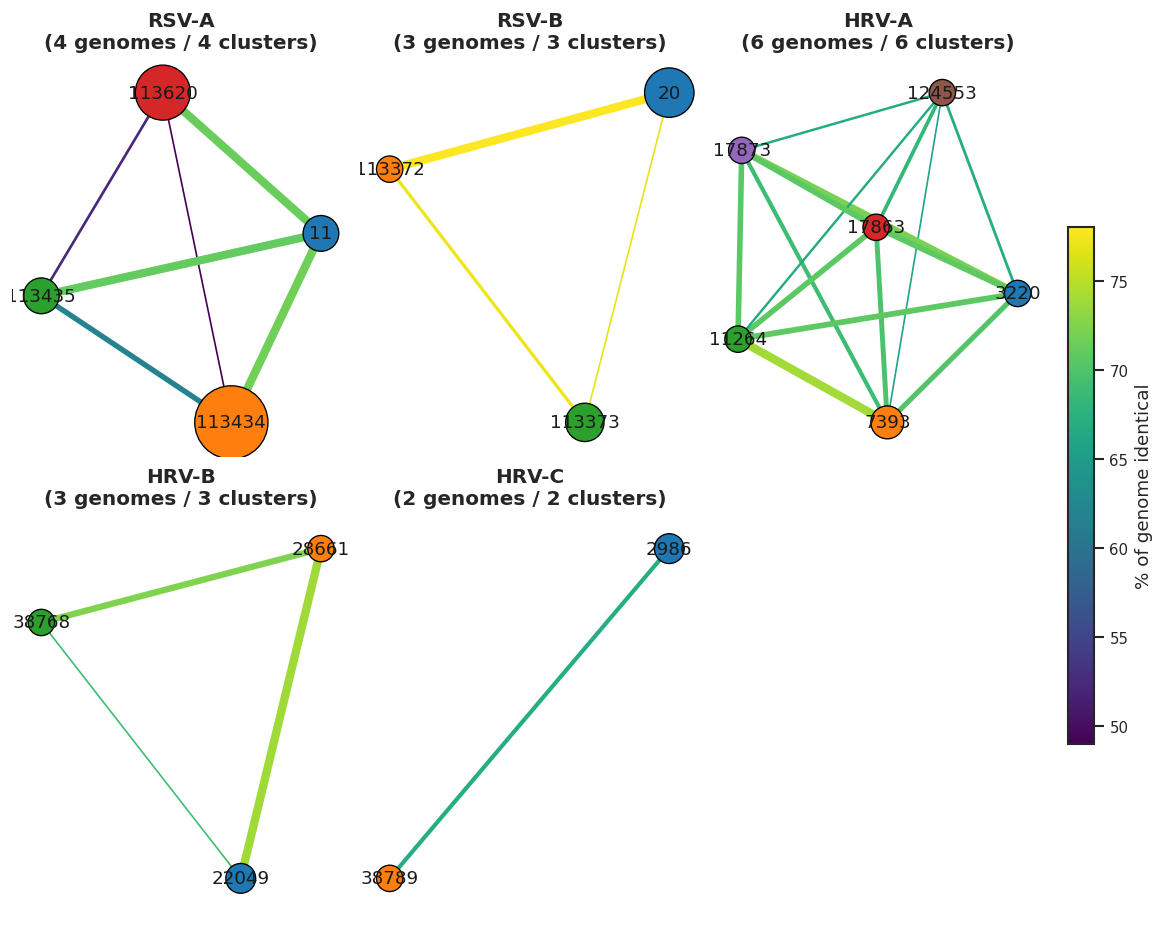

Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7/plots/figure_7_subtype_ani_networks.png


In [58]:
import gzip
import itertools
import subprocess
import tempfile

import networkx as nx
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

WORKDIR = OUT / "work/subtype_ani_networks"
FASTA_DIR = WORKDIR / "fastas"
FASTA_DIR.mkdir(parents=True, exist_ok=True)
FASTA_GZ = OUT / "refs/genomes/uhvdb.species_reps.fna.gz"
BLASTN = "/sw/contrib/coenv-src/blast+/2.17.0/bin/blastn"
MAKEBLASTDB = "/sw/contrib/coenv-src/blast+/2.17.0/bin/makeblastdb"

if "id2sub" not in globals() or "VIRUS_AXES" not in globals():
    _map = pd.read_csv(OUT / "uhvdb_virus_subtype_map.tsv", sep="\t")
    id2sub = dict(zip(_map["uhvdb_id"], _map["subtype"]))
    VIRUS_AXES = ["RSVA", "RSVB", "NL63", "OC43", "229E", "HRV_A", "HRV_B", "HRV_C", "HBoV"]
    COV_THR = 3.0
if "VIRUS_LABELS" not in globals():
    VIRUS_LABELS = {
        "RSVA": "RSV-A", "RSVB": "RSV-B", "NL63": "HCoV-NL63", "OC43": "HCoV-OC43",
        "229E": "HCoV-229E", "HRV_A": "HRV-A", "HRV_B": "HRV-B", "HRV_C": "HRV-C", "HBoV": "HBoV",
    }

cluster_meta = pd.read_csv(
    METADATA, sep="\t", usecols=["uhvdb_id", "species_rep", "species_cluster_id"], low_memory=False,
).drop_duplicates("uhvdb_id")
id2cl = dict(zip(cluster_meta["uhvdb_id"], cluster_meta["species_cluster_id"]))
id2srep = dict(zip(cluster_meta["uhvdb_id"], cluster_meta["species_rep"]))

# # --- 1) max sylph ANI genome per sample × subtype ---
# best_rows = []
# for d in sorted(RESULTS.iterdir()):
#     prof = d / f"{d.name}.profile.tsv"
#     if not d.is_dir() or not prof.is_file():
#         continue
#     best = {}
#     with prof.open() as fh:
#         for row in csv.DictReader(fh, delimiter="\t"):
#             if "uhvdb" not in row["Genome_file"]:
#                 continue
#             uid = row["Contig_name"].split()[0]
#             sub = id2sub.get(uid)
#             if sub not in VIRUS_AXES:
#                 continue
#             cov = float(row["True_cov"])
#             if cov < COV_THR:
#                 continue
#             ani = float(row["Adjusted_ANI"])
#             prev = best.get(sub)
#             if prev is None or ani > prev["sylph_ani"] or (ani == prev["sylph_ani"] and cov > prev["True_cov"]):
#                 best[sub] = {
#                     "sample": d.name, "subtype": sub, "uhvdb_id": uid,
#                     "species_rep": id2srep.get(uid, uid),
#                     "species_cluster_id": id2cl.get(uid),
#                     "sylph_ani": ani, "True_cov": cov,
#                 }
#     best_rows.extend(best.values())

# best_hits = pd.DataFrame(best_rows)
# best_hits.to_csv(OUT / "human_virus_maxani_per_sample.tsv", sep="\t", index=False)
# print("Max-ANI genome per sample × subtype (cov ≥ 3):")
# display(
#     best_hits.groupby("subtype").agg(
#         n_samples=("sample", "nunique"),
#         n_genomes=("uhvdb_id", "nunique"),
#         n_clusters=("species_cluster_id", "nunique"),
#         median_sylph_ani=("sylph_ani", "median"),
#     ).reindex(VIRUS_AXES)
# )

# # --- extract sequences ---
# needed = sorted(set(best_hits["uhvdb_id"]))
# wanted = set(needed)
# found = {}
# buf_id, buf = None, []
# with gzip.open(FASTA_GZ, "rt") as fh:
#     for line in fh:
#         if line.startswith(">"):
#             if buf_id in wanted:
#                 found[buf_id] = "".join(buf)
#             hdr = line[1:].strip().split()[0]
#             buf_id = hdr if hdr in wanted else None
#             buf = []
#         elif buf_id is not None:
#             buf.append(line.strip())
#     if buf_id in wanted:
#         found[buf_id] = "".join(buf)
# missing = [g for g in needed if g not in found]
# assert not missing, f"Missing from species_reps fasta: {missing}"
# for g, seq in found.items():
#     (FASTA_DIR / f"{g}.fna").write_text(f">{g}\n{seq}\n")
# print(f"Extracted {len(found)} genomes to {FASTA_DIR}")


# def blast_ani_af(fa, fb):
#     sa = "".join(l for l in Path(fa).read_text().splitlines() if not l.startswith(">"))
#     sb = "".join(l for l in Path(fb).read_text().splitlines() if not l.startswith(">"))
#     la, lb = len(sa), len(sb)
#     with tempfile.TemporaryDirectory() as td:
#         td = Path(td)
#         qa, qb = td / "a.fna", td / "b.fna"
#         qa.write_text(Path(fa).read_text()); qb.write_text(Path(fb).read_text())
#         subprocess.run([MAKEBLASTDB, "-in", str(qb), "-dbtype", "nucl", "-out", str(td / "db")],
#                        check=True, capture_output=True)
#         subprocess.run([MAKEBLASTDB, "-in", str(qa), "-dbtype", "nucl", "-out", str(td / "db2")],
#                        check=True, capture_output=True)
#         out_ab = subprocess.check_output([
#             BLASTN, "-query", str(qa), "-db", str(td / "db"), "-task", "blastn",
#             "-evalue", "1e-5", "-outfmt", "6 qstart qend pident length", "-max_hsps", "100",
#         ], text=True)
#         out_ba = subprocess.check_output([
#             BLASTN, "-query", str(qb), "-db", str(td / "db2"), "-task", "blastn",
#             "-evalue", "1e-5", "-outfmt", "6 qstart qend pident length", "-max_hsps", "100",
#         ], text=True)

#     def covered_identity(txt, qlen):
#         if not txt.strip():
#             return 0.0, 0.0
#         ivals, id_bp, aln_bp = [], 0.0, 0
#         for line in txt.strip().splitlines():
#             qs, qe, pident, length = line.split("\t")
#             qs, qe, length = int(qs), int(qe), int(length)
#             if qs > qe:
#                 qs, qe = qe, qs
#             ivals.append((qs, qe))
#             id_bp += float(pident) / 100.0 * length
#             aln_bp += length
#         ivals.sort()
#         merged = []
#         for s, e in ivals:
#             if not merged or s > merged[-1][1] + 1:
#                 merged.append([s, e])
#             else:
#                 merged[-1][1] = max(merged[-1][1], e)
#         cov = sum(e - s + 1 for s, e in merged)
#         return (100.0 * id_bp / aln_bp if aln_bp else 0.0,
#                 100.0 * cov / qlen if qlen else 0.0)

#     ani_ab, af_a = covered_identity(out_ab, la)
#     ani_ba, af_b = covered_identity(out_ba, lb)
#     anis = [x for x in (ani_ab, ani_ba) if x > 0]
#     ani = float(np.mean(anis)) if anis else 0.0
#     af = min(af_a, af_b)
#     return ani, af_a, af_b, af


# # --- 2) pairwise blastn ANI/AF for all multi-cluster subtypes ---
# pair_rows, multi_subtypes = [], []
# g2cl = best_hits.drop_duplicates("uhvdb_id").set_index("uhvdb_id")["species_cluster_id"].to_dict()
# g2n = best_hits.groupby("uhvdb_id")["sample"].nunique().to_dict()
# for sub in VIRUS_AXES:
#     genomes = sorted(best_hits.loc[best_hits.subtype == sub, "uhvdb_id"].unique())
#     n_cl = best_hits.loc[best_hits.subtype == sub, "species_cluster_id"].nunique()
#     if n_cl < 2 or len(genomes) < 2:
#         continue
#     multi_subtypes.append(sub)
#     rows = []
#     for a, b in itertools.combinations(genomes, 2):
#         ani, af_a, af_b, af = blast_ani_af(FASTA_DIR / f"{a}.fna", FASTA_DIR / f"{b}.fna")
#         rows.append({
#             "subtype": sub, "genome_a": a, "genome_b": b,
#             "cluster_a": g2cl[a], "cluster_b": g2cl[b],
#             "ANI": ani, "AF": af, "AF_a": af_a, "AF_b": af_b,
#             "ANI_x_AF": ani * af / 100.0,
#             "method": "blastn",
#             "n_samples_a": g2n.get(a, 1), "n_samples_b": g2n.get(b, 1),
#         })
#     pair_rows.append(pd.DataFrame(rows))
#     print(f"{sub}: {len(rows)} blastn pairs")

# pairs = pd.concat(pair_rows, ignore_index=True)
# pairs.to_csv(OUT / "human_virus_pairwise_ani_af.tsv", sep="\t", index=False)
# print("\nPairwise blastn ANI/AF summary:")
# display(pairs.groupby("subtype").agg(
#     n_pairs=("ANI", "size"), median_ANI=("ANI", "median"),
#     median_AF=("AF", "median"), median_ANI_x_AF=("ANI_x_AF", "median"),
# ))

# --- 3) networks: edges colored/weighted by ANI×AF; colorbar scale (no edge text labels) ---
# Reload pairwise results if needed (e.g. after commenting out blastn recompute above)
if "pairs" not in globals() or pairs is None or len(pairs) == 0:
    pairs = pd.read_csv(OUT / "human_virus_pairwise_ani_af.tsv", sep="\t")
if "best_hits" not in globals() or best_hits is None or len(best_hits) == 0:
    best_hits = pd.read_csv(OUT / "human_virus_maxani_per_sample.tsv", sep="\t")
g2cl = best_hits.drop_duplicates("uhvdb_id").set_index("uhvdb_id")["species_cluster_id"].to_dict()
g2n = best_hits.groupby("uhvdb_id")["sample"].nunique().to_dict()
multi_subtypes = [
    s for s in VIRUS_AXES
    if pairs.loc[pairs.subtype == s, "genome_a"].nunique()
    + pairs.loc[pairs.subtype == s, "genome_b"].nunique() >= 2
    and pairs.loc[pairs.subtype == s, ["cluster_a", "cluster_b"]].stack().nunique() >= 2
]

# Shared color scale across panels
score_all = pairs["ANI_x_AF"].to_numpy()
vmin, vmax = float(np.nanmin(score_all)), float(np.nanmax(score_all))
edge_cmap = plt.cm.viridis
norm = Normalize(vmin=vmin, vmax=vmax)

ncols, nrows = 3, int(np.ceil(len(multi_subtypes) / 3))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.8 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
for ax, sub in zip(axes, multi_subtypes):
    sub_pairs = pairs[pairs.subtype == sub]
    G = nx.Graph()
    for g in sorted(set(sub_pairs.genome_a) | set(sub_pairs.genome_b)):
        G.add_node(g, cluster=g2cl[g], n_samples=int(g2n.get(g, 1)))
    for _, r in sub_pairs.iterrows():
        if r.ANI > 0 and r.AF > 0:
            G.add_edge(r.genome_a, r.genome_b, ANI=r.ANI, AF=r.AF, ANI_x_AF=r.ANI_x_AF)
    pos = nx.spring_layout(G, seed=2, weight="ANI_x_AF", k=1.4 / np.sqrt(max(len(G), 1)))
    clusters = [G.nodes[n]["cluster"] for n in G.nodes]
    uniq = sorted(set(clusters), key=lambda x: (str(type(x)), x))
    node_cmap = plt.cm.tab10
    color_map = {c: node_cmap(i % 10) for i, c in enumerate(uniq)}
    scores = [G.edges[e]["ANI_x_AF"] for e in G.edges] or [vmin]
    smin, smax = min(scores), max(scores)
    widths = (
        [1.0 + 4.0 * ((s - smin) / (smax - smin)) for s in scores]
        if smax > smin else [2.5] * len(scores)
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax, width=widths, edge_color=scores,
        edge_cmap=edge_cmap, edge_vmin=vmin, edge_vmax=vmax,
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=[color_map[c] for c in clusters],
        node_size=[180 + 70 * G.nodes[n]["n_samples"] for n in G.nodes],
        linewidths=0.8, edgecolors="black",
    )
    nx.draw_networkx_labels(
        G, pos, labels={n: str(G.nodes[n]["cluster"]) for n in G.nodes}, ax=ax, font_size=11,
    )
    ax.set_title(
        f"{VIRUS_LABELS[sub]}\n({G.number_of_nodes()} genomes / {len(uniq)} clusters)",
        fontweight="bold", fontsize=12,
    )
    ax.axis("off")
for j in range(len(multi_subtypes), len(axes)):
    axes[j].axis("off")

# Shared color scale (% of genome identical)
sm = ScalarMappable(norm=norm, cmap=edge_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:len(multi_subtypes)], fraction=0.025, pad=0.02, shrink=0.85)
cbar.set_label("% of genome identical", fontsize=11)
cbar.ax.tick_params(labelsize=9)

fig.savefig(PLOTS / "figure_7_subtype_ani_networks.png", dpi=300, bbox_inches="tight")
fig.savefig(PLOTS / "figure_7_subtype_ani_networks.pdf", bbox_inches="tight")
plt.show()
print("Wrote", PLOTS / "figure_7_subtype_ani_networks.png")


## 10. Bacteria / phage / eukaryotic RNA composition + clinical mosaic

Stacked taxonomic abundance per sample:
- **Bacteria** — GTDB hits
- **Phage** — UHVDB DNA-realm viruses (`Duplodnaviria` / `Monodnaviria` / `Varidnaviria`)
- **Eukaryotic RNA virus** — UHVDB `Riboviria`

Thin mosaic underneath: clinical panel subtypes detected at sylph depth ≥ 3.

Samples ordered by eukaryotic RNA virus taxonomic abundance (highest → lowest).

Writes `plots/figure_7_composition_mosaic.{png,pdf}` plus TSVs.


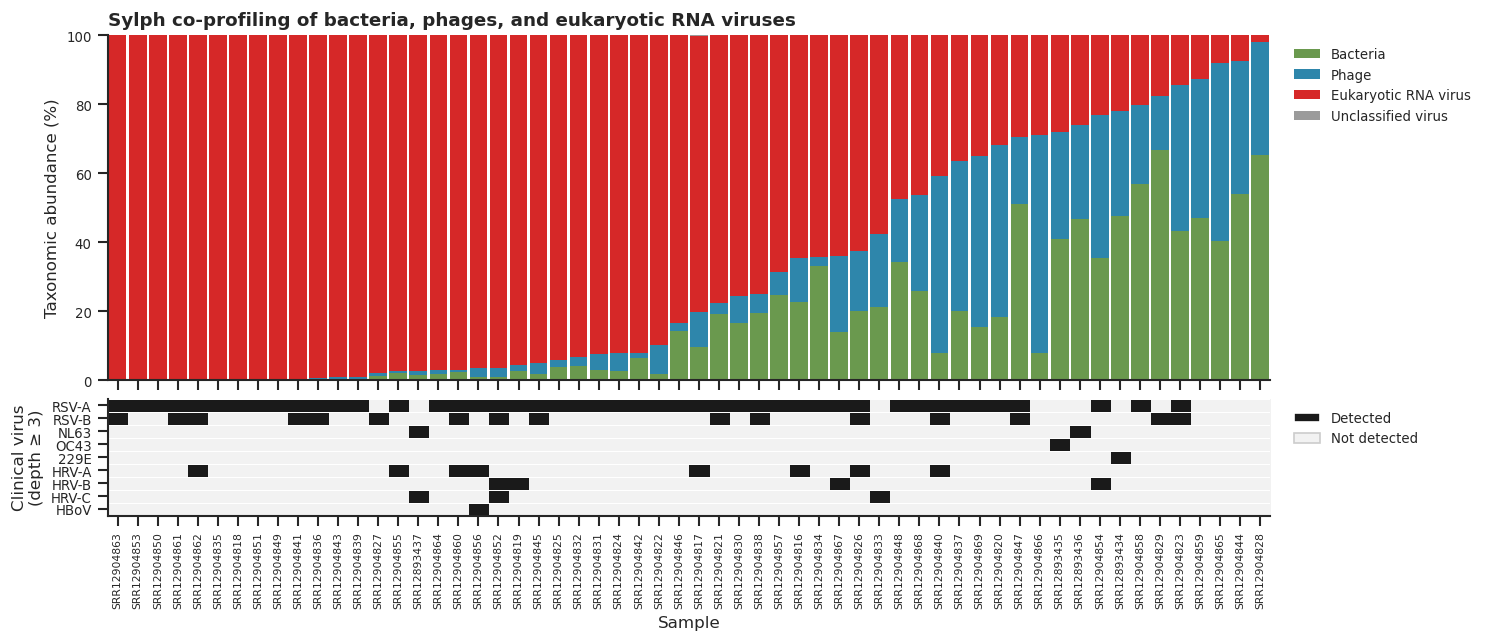

Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_7/plots/figure_7_composition_mosaic.png
Median abundance (%):
Bacteria                 7.869958
Phage                    4.920297
Eukaryotic RNA virus    81.609260
Unclassified virus       0.000000
Clinical detections: {'RSVA': 46, 'RSVB': 16, 'NL63': 2, 'OC43': 1, '229E': 1, 'HRV_A': 8, 'HRV_B': 4, 'HRV_C': 3, 'HBoV': 1}


In [54]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

COV_THR_MOSAIC = 3.0
PANEL_AXES = ["RSVA", "RSVB", "NL63", "OC43", "229E", "HRV_A", "HRV_B", "HRV_C", "HBoV"]
PANEL_LABELS = {
    "RSVA": "RSV-A", "RSVB": "RSV-B", "NL63": "NL63", "OC43": "OC43",
    "229E": "229E", "HRV_A": "HRV-A", "HRV_B": "HRV-B", "HRV_C": "HRV-C", "HBoV": "HBoV",
}
COMP_COLORS = {
    "Bacteria": "#6A994E",
    "Phage": "#2E86AB",
    "Eukaryotic RNA virus": "#D62828",
    "Unclassified virus": "#9B9B9B",
}
# Map UHVDB ids → composition class
if "rep_type" not in globals():
    raise RuntimeError("Run §1 first (rep_type / nucleic-acid map)")

# Remap DNA/RNA labels to Bacteria–Phage–Eukaryotic RNA for this figure
comp_type = {}
for sid, lab in rep_type.items():
    if lab == "RNA virus":
        comp_type[sid] = "Eukaryotic RNA virus"
    elif lab == "DNA virus":
        comp_type[sid] = "Phage"
    else:
        comp_type[sid] = "Unclassified virus"

if "id2sub" not in globals():
    _map = pd.read_csv(OUT / "uhvdb_virus_subtype_map.tsv", sep="\t")
    id2sub = dict(zip(_map["uhvdb_id"], _map["subtype"]))

_matches = OUT / "likely_phenotype_matches.tsv"
_pheno = {}
if _matches.is_file():
    _ph = pd.read_csv(_matches, sep="\t")
    _pheno = dict(zip(_ph["sample"], _ph["SampleGroup"]))

comp_rows, mosaic_rows = [], []
for d in sorted(RESULTS.iterdir()):
    prof = d / f"{d.name}.profile.tsv"
    if not d.is_dir() or not prof.is_file() or prof.stat().st_size == 0:
        continue
    abund = {"Bacteria": 0.0, "Phage": 0.0, "Eukaryotic RNA virus": 0.0, "Unclassified virus": 0.0}
    clin = {a: 0.0 for a in PANEL_AXES}
    with prof.open() as fh:
        for row in csv.DictReader(fh, delimiter="\t"):
            ab = float(row["Taxonomic_abundance"])
            gf = row["Genome_file"]
            uid = row["Contig_name"].split()[0]
            cov = float(row["True_cov"])
            if "gtdb" in gf:
                abund["Bacteria"] += ab
            elif "uhvdb" in gf:
                cat = comp_type.get(uid, "Unclassified virus")
                abund[cat] = abund.get(cat, 0.0) + ab
                sub = id2sub.get(uid)
                if sub in clin:
                    clin[sub] = max(clin[sub], cov)
    total = sum(abund.values()) or 1.0
    frac = {k: 100.0 * v / total for k, v in abund.items()}
    comp_rows.append({
        "sample": d.name,
        "phenotype": _pheno.get(d.name, "unknown"),
        **frac,
        "rna_raw": abund["Eukaryotic RNA virus"],
    })
    mosaic_rows.append({"sample": d.name, **{a: int(clin[a] >= COV_THR_MOSAIC) for a in PANEL_AXES}})

comp = pd.DataFrame(comp_rows)
mosaic = pd.DataFrame(mosaic_rows).set_index("sample")
comp = comp.sort_values("rna_raw", ascending=False).reset_index(drop=True)
sample_order = comp["sample"].tolist()
mosaic = mosaic.loc[sample_order]

comp.to_csv(OUT / "human_virus_phage_bacteria_composition.tsv", sep="\t", index=False)
mosaic.reset_index().to_csv(OUT / "human_virus_clinical_presence_mosaic.tsv", sep="\t", index=False)

# plot
_saved = plt.rcParams.copy()
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11, "axes.labelsize": 12, "axes.titlesize": 13,
    "xtick.labelsize": 10, "ytick.labelsize": 11,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

n = len(sample_order)
fig = plt.figure(figsize=(7.5, 5.8))
gs = fig.add_gridspec(2, 1, height_ratios=[2.8, 1.6], hspace=0.12)
ax = fig.add_subplot(gs[0])
axm = fig.add_subplot(gs[1], sharex=ax)

x = np.arange(n)
bottom = np.zeros(n)
stack_order = ["Bacteria", "Phage", "Eukaryotic RNA virus"]
if comp["Unclassified virus"].sum() > 1e-6:
    stack_order.append("Unclassified virus")
for lab in stack_order:
    vals = comp[lab].to_numpy()
    ax.bar(x, vals, bottom=bottom, width=0.88, color=COMP_COLORS[lab], edgecolor="none", label=lab)
    bottom += vals

ax.set_ylim(0, 100)
ax.set_ylabel("Taxonomic abundance (%)")
ax.set_title("Sylph co-profiling of bacteria, phages, and eukaryotic RNA viruses",
             fontweight="bold", loc="left")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=10)
sns.despine(ax=ax)
ax.tick_params(axis="x", labelbottom=False)

mat = mosaic[PANEL_AXES].to_numpy().T
axm.imshow(
    mat, aspect="auto", interpolation="nearest",
    cmap=ListedColormap(["#F2F2F2", "#1A1A1A"]), vmin=0, vmax=1,
    extent=(-0.5, n - 0.5, len(PANEL_AXES) - 0.5, -0.5),
)
axm.set_yticks(np.arange(len(PANEL_AXES)))
axm.set_yticklabels([PANEL_LABELS[a] for a in PANEL_AXES], fontsize=10)
axm.tick_params(axis="y", length=0, pad=4)
axm.set_xticks([])
axm.set_xlabel("Sample")
axm.set_ylabel("")
for y in np.arange(-0.5, len(PANEL_AXES), 1):
    axm.axhline(y, color="white", lw=0.8)
sns.despine(ax=axm)
axm.legend(
    handles=[
        Patch(facecolor="#1A1A1A", label="Detected (depth ≥ 3)"),
        Patch(facecolor="#F2F2F2", edgecolor="#CCCCCC", label="Not detected"),
    ],
    frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=10,
)

fig.savefig(PLOTS / "figure_7_composition_mosaic.png", dpi=300, bbox_inches="tight")
fig.savefig(PLOTS / "figure_7_composition_mosaic.pdf", bbox_inches="tight")
plt.show()
plt.rcParams.update(_saved)
print("Wrote", PLOTS / "figure_7_composition_mosaic.png")
print("Median abundance (%):")
print(comp[stack_order].median().to_string())
print("Clinical detections:", mosaic.sum().astype(int).to_dict())
